# White-Box vs. Black-Box: A Quantitative Comparison

`attacks/whitebox/01_HotFlip.ipynb` (white-box, gradient-guided) and `attacks/blackbox/01_SynonymSubstitution.ipynb`
(black-box, query-only) both attack the same model. This notebook runs both against a real
sample from the SST-2 validation set and reports the same three numbers the vision repo's
`robustness_evaluation/generate_adversarial_dataset.ipynb` reports for images: **Attack Success
Rate**, **average perturbation size** (here: fraction of words changed, the text analogue of
$L_2$ distortion), and **cost** (here: number of model queries, since gradient access has no
direct query-count equivalent, HotFlip's cost is reported as "N/A, gradient access" instead).


In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

import torch
import torch.nn.functional as F
import nltk
from nltk.corpus import wordnet, stopwords
from transformers import AutoTokenizer, AutoModelForSequenceClassification

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('stopwords', quiet=True)
STOPWORDS = set(stopwords.words('english'))

### Setup
Same target model as both attack notebooks. `SAMPLE_SIZE` sentences are drawn from the real
SST-2 validation split (not hand-picked examples), kept small for this first pass, the same
"validate small, then scale up" convention used throughout the vision repo's evaluation
pipeline.

In [2]:
MODEL_NAME = 'distilbert-base-uncased-finetuned-sst-2-english'
SAMPLE_SIZE = 15

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()
LABELS = model.config.id2label

sst2 = load_dataset('stanfordnlp/sst2', split='validation')
sentences = [s for s in sst2['sentence'][:SAMPLE_SIZE * 2] if len(s.split()) >= 5][:SAMPLE_SIZE]
print(f"Loaded {len(sentences)} SST-2 validation sentences")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

README.md:   0%|          | 0.00/5.27k [00:00<?, ?B/s]

C:\Users\frang\Desktop\adv_at\adversarial_attacks_nlp\.venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\frang\.cache\huggingface\hub\datasets--stanfordnlp--sst2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Loaded 15 SST-2 validation sentences


In [3]:
@torch.no_grad()
def predict(text):
    inputs = tokenizer(text, return_tensors='pt')
    probs = F.softmax(model(**inputs).logits, dim=-1)[0]
    label_idx = int(torch.argmax(probs))
    return LABELS[label_idx], float(probs[label_idx]), label_idx

@torch.no_grad()
def predict_proba(text, label_idx):
    inputs = tokenizer(text, return_tensors='pt')
    probs = F.softmax(model(**inputs).logits, dim=-1)[0]
    return float(probs[label_idx])

embedding_matrix = model.get_input_embeddings().weight
SPECIAL_TOKEN_IDS = set(tokenizer.all_special_ids)

def hotflip_step(input_ids, true_label_idx):
    embeds = embedding_matrix[input_ids].clone().detach().unsqueeze(0)
    embeds.requires_grad_(True)
    logits = model(inputs_embeds=embeds).logits
    loss = F.cross_entropy(logits, torch.tensor([true_label_idx]))
    loss.backward()
    grad = embeds.grad[0]

    best_score, best_pos, best_candidate = float('-inf'), None, None
    for pos in range(len(input_ids)):
        if input_ids[pos].item() in SPECIAL_TOKEN_IDS:
            continue
        current_embed = embedding_matrix[input_ids[pos]]
        scores = (embedding_matrix - current_embed) @ grad[pos]
        candidate_id = int(torch.argmax(scores))
        if scores[candidate_id] > best_score:
            best_score = float(scores[candidate_id])
            best_pos, best_candidate = pos, candidate_id
    return best_pos, best_candidate

def hotflip_attack(text, max_flips=5):
    input_ids = tokenizer(text, return_tensors='pt')['input_ids'][0]
    _, _, true_label_idx = predict(text)
    n_flips = 0
    for _ in range(max_flips):
        pos, candidate_id = hotflip_step(input_ids, true_label_idx)
        input_ids = input_ids.clone()
        input_ids[pos] = candidate_id
        n_flips += 1
        adv_text = tokenizer.decode(input_ids, skip_special_tokens=True)
        _, _, current_label_idx = predict(adv_text)
        if current_label_idx != true_label_idx:
            break
    return tokenizer.decode(input_ids, skip_special_tokens=True), n_flips

POS_MAP = {'NN': wordnet.NOUN, 'VB': wordnet.VERB, 'JJ': wordnet.ADJ, 'RB': wordnet.ADV}

def get_synonyms(word, pos_tag, max_candidates=8):
    wn_pos = POS_MAP.get(pos_tag[:2])
    if wn_pos is None:
        return []
    synonyms = set()
    for syn in wordnet.synsets(word, pos=wn_pos):
        for lemma in syn.lemmas():
            candidate = lemma.name().replace('_', ' ')
            if candidate.lower() != word.lower():
                synonyms.add(candidate)
    return list(synonyms)[:max_candidates]

def synonym_attack(text, max_words_to_replace=10):
    words = text.split()
    pos_tags = [tag for _, tag in nltk.pos_tag(words)]
    _, _, true_label_idx = predict(text)

    base_prob = predict_proba(text, true_label_idx)
    queries_used = 1
    importances = []
    for i in range(len(words)):
        if words[i].lower() in STOPWORDS:
            importances.append((i, -1.0))
            continue
        without_word = words[:i] + words[i + 1:]
        prob_without = predict_proba(' '.join(without_word), true_label_idx)
        queries_used += 1
        importances.append((i, base_prob - prob_without))
    order = [i for i, _ in sorted(importances, key=lambda x: x[1], reverse=True)]

    n_substitutions = 0
    for count, i in enumerate(order):
        if count >= max_words_to_replace:
            break
        current_prob = predict_proba(' '.join(words), true_label_idx)
        queries_used += 1
        best_word, best_prob = words[i], current_prob
        for candidate in get_synonyms(words[i], pos_tags[i]):
            trial_words = words[:i] + [candidate] + words[i + 1:]
            trial_prob = predict_proba(' '.join(trial_words), true_label_idx)
            queries_used += 1
            if trial_prob < best_prob:
                best_word, best_prob = candidate, trial_prob
        if best_word != words[i]:
            words[i] = best_word
            n_substitutions += 1
        _, _, current_label_idx = predict(' '.join(words))
        if current_label_idx != true_label_idx:
            break
    return ' '.join(words), n_substitutions, queries_used

### Running Both Attacks
Every sentence is attacked once by each method, using the model's own clean prediction as the
reference label, the same unlabeled-sample convention used throughout the vision repo.

In [4]:
rows = []

for sentence in sentences:
    _, _, true_label_idx = predict(sentence)
    n_words = len(sentence.split())

    start = time.time()
    hf_text, hf_flips = hotflip_attack(sentence)
    hf_time = time.time() - start
    _, _, hf_label_idx = predict(hf_text)

    start = time.time()
    syn_text, syn_subs, syn_queries = synonym_attack(sentence)
    syn_time = time.time() - start
    _, _, syn_label_idx = predict(syn_text)

    rows.append({
        'Attack': 'HotFlip', 'Success': hf_label_idx != true_label_idx,
        'Pct_Words_Changed': 100 * hf_flips / n_words, 'Queries': None, 'Time_Sec': hf_time,
    })
    rows.append({
        'Attack': 'Synonym Substitution', 'Success': syn_label_idx != true_label_idx,
        'Pct_Words_Changed': 100 * syn_subs / n_words, 'Queries': syn_queries, 'Time_Sec': syn_time,
    })

results_df = pd.DataFrame(rows)
results_df.to_csv('attack_comparison.csv', index=False)
print(f"Saved {len(results_df)} rows -> attack_comparison.csv")

C:\Users\frang\AppData\Local\Temp\ipykernel_25216\4098843221.py:33: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:821.)
  best_score = float(scores[candidate_id])


Saved 30 rows -> attack_comparison.csv


### White-Box vs. Black-Box: The Trade-Off
Gradient access (HotFlip) versus query-only access (Synonym Substitution): which wins on attack
success rate, and at what cost in words changed and (for the black-box attack) queries spent?

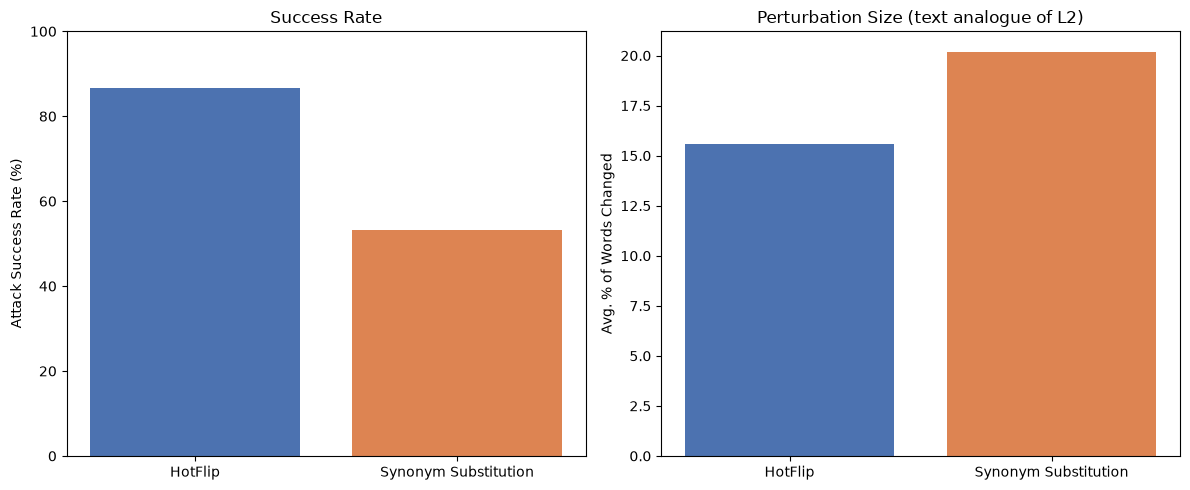

,ASR,Avg_Pct_Words_Changed,Avg_Queries,Avg_Time_Sec,N
Attack,,,,,
HotFlip,86.7,15.6,NaN,1.069572,15
Synonym Substitution,53.3,20.2,41.333333,1.555392,15


In [5]:
summary = results_df.groupby('Attack').agg(
    ASR=('Success', 'mean'), Avg_Pct_Words_Changed=('Pct_Words_Changed', 'mean'),
    Avg_Queries=('Queries', 'mean'), Avg_Time_Sec=('Time_Sec', 'mean'), N=('Success', 'count'),
)
summary['ASR'] = (summary['ASR'] * 100).round(1)
summary['Avg_Pct_Words_Changed'] = summary['Avg_Pct_Words_Changed'].round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(summary.index, summary['ASR'], color=['#4C72B0', '#DD8452'])
axes[0].set_ylabel('Attack Success Rate (%)')
axes[0].set_ylim(0, 100)
axes[0].set_title('Success Rate')

axes[1].bar(summary.index, summary['Avg_Pct_Words_Changed'], color=['#4C72B0', '#DD8452'])
axes[1].set_ylabel('Avg. % of Words Changed')
axes[1].set_title('Perturbation Size (text analogue of L2)')

plt.tight_layout()
plt.show()

summary